Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data and getting basic info

In [3]:
df = pd.read_csv("../Data/diagnosis_dataset.csv")

# Show first rows
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe(include="all"))

   Patient_ID  Age  Gender  Heart_Rate_bpm  Body_Temperature_C  \
0           1   53    Male             107               39.67   
1           2   39  Female              89               38.25   
2           3   54    Male              94               38.46   
3           4   57    Male              79               39.16   
4           5   51    Male             107               39.14   

   Oxygen_Saturation_%            Symptom_1   Symptom_2            Symptom_3  \
0                91.06             Headache  Runny nose           Runny nose   
1                91.20                Fever       Cough          Sore throat   
2                88.73          Sore throat       Fever  Shortness of breath   
3                96.05  Shortness of breath     Fatigue          Sore throat   
4                91.80                Fever       Fever             Headache   

  Blood_Pressure_mmHg Severity                  Treatment_Plan   Diagnosis  
0             136/101   Severe  Hospitalizati

Insights-

-No Missing Values
-Correct Data Types
-Normal Value Ranges

In [4]:
# Blood pressure has combined value so split it
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)
df

,Patient_ID,Age,Gender,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Symptom_1,Symptom_2,Symptom_3,Severity,Treatment_Plan,Diagnosis,Systolic_BP,Diastolic_BP
0,1,53,Male,107,39.67,91.06,Headache,Runny nose,Runny nose,Severe,Hospitalization and medication,Pneumonia,136,101
1,2,39,Female,89,38.25,91.20,Fever,Cough,Sore throat,Severe,Hospitalization and medication,Bronchitis,138,88
2,3,54,Male,94,38.46,88.73,Sore throat,Fever,Shortness of breath,Mild,Rest and fluids,Healthy,120,73
3,4,57,Male,79,39.16,96.05,Shortness of breath,Fatigue,Sore throat,Mild,Rest and fluids,Healthy,119,75
4,5,51,Male,107,39.14,91.80,Fever,Fever,Headache,Severe,Hospitalization and medication,Pneumonia,142,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,74,Male,84,35.90,96.00,Runny nose,Runny nose,Shortness of breath,Mild,Rest and fluids,Cold,109,69
1996,1997,40,Female,113,36.19,97.68,Runny nose,Sore throat,Body ache,Mild,Rest and fluids,Cold,121,72
1997,1998,54,Male,97,35.94,96.94,Body ache,Cough,Fatigue,Mild,Rest and fluids,Healthy,125,74
1998,1999,50,Male,90,37.42,93.94,Sore throat,Body ache,Runny nose,Severe,Hospitalization and medication,Bronchitis,114,71


In [5]:
# Convert categorical columns to category dtype
cat_cols = ["Gender", "Symptom_1", "Symptom_2", "Symptom_3", 
            "Diagnosis", "Severity", "Treatment_Plan"]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

Univariate Analysis

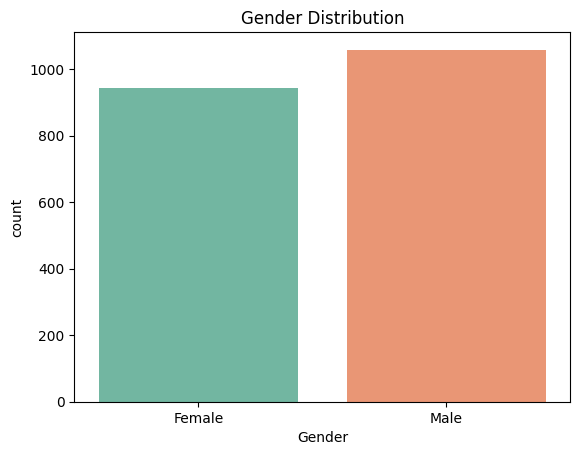

In [6]:
# Gender counts
sns.countplot(data=df, x="Gender",hue="Gender", palette="Set2")
plt.title("Gender Distribution")
plt.show()

Insights-
-Gender distribution is almost balanced

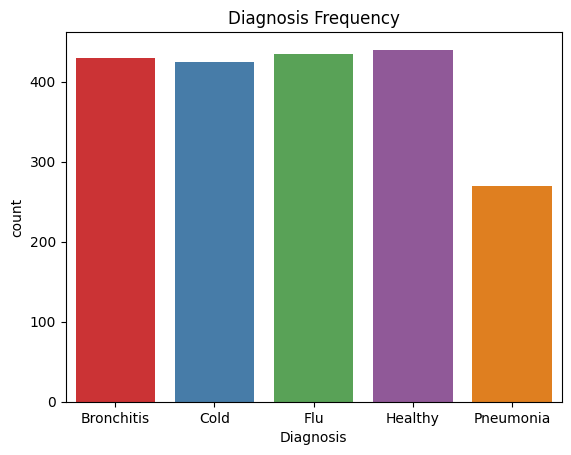

In [7]:
# Diagnosis counts
sns.countplot(data=df, x="Diagnosis",hue="Diagnosis", palette="Set1")
plt.title("Diagnosis Frequency")
plt.show()

Insights-
-Healthy is the most frequent category
-Bronchitis, Cold, and Flu—are all well-represented and have almost similar count
-Pneumonia is the distinct minority class
-There is imbalance issue ,need to resolve

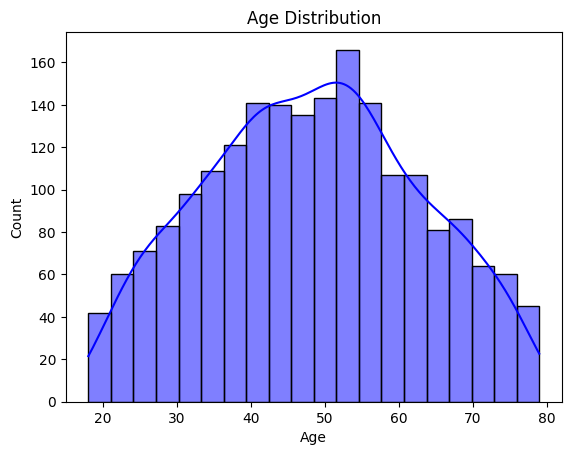

In [8]:
# Age distribution
sns.histplot(df["Age"], kde=True, bins=20, color="blue")
plt.title("Age Distribution")
plt.show()

Insights-
-The vast majority of patients are middle-aged adults, roughly between 35 and 60 years old

Symptoms Analysis

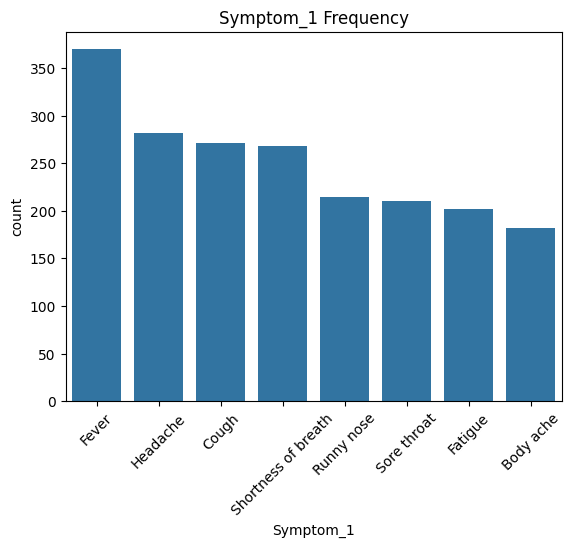

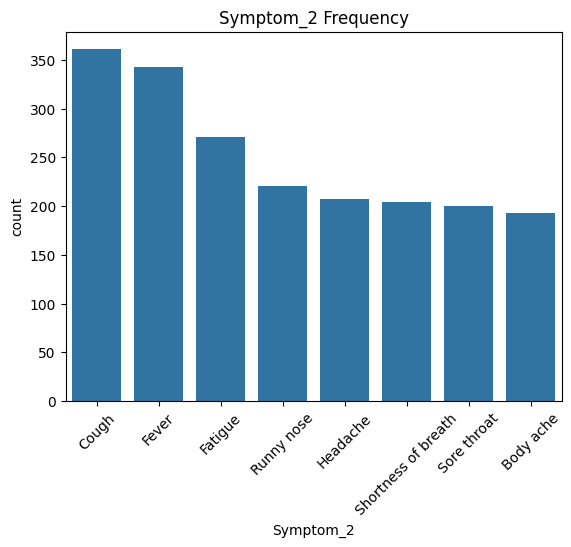

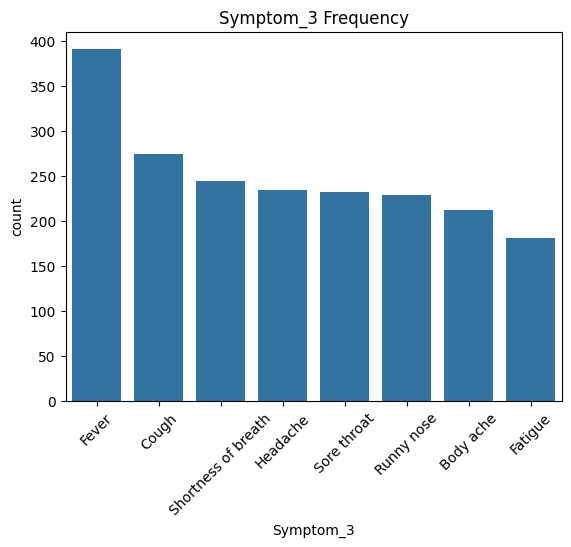

In [9]:
for symptom in ["Symptom_1", "Symptom_2", "Symptom_3"]:
    if symptom in df.columns:
        sns.countplot(data=df, x=symptom, order=df[symptom].value_counts().index)
        plt.title(f"{symptom} Frequency")
        plt.xticks(rotation=45)
        plt.show()

Insights-
-Cough and Fever are consistently the most frequent primary, secondary, and tertiary symptoms.
-The distribution of all 8 symptoms is relatively balanced within each symptom column

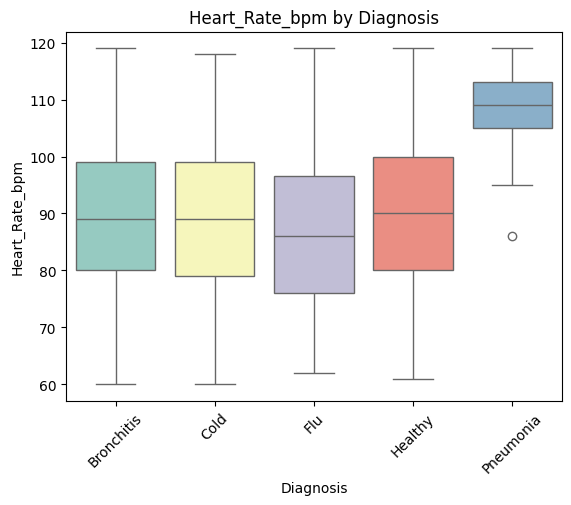

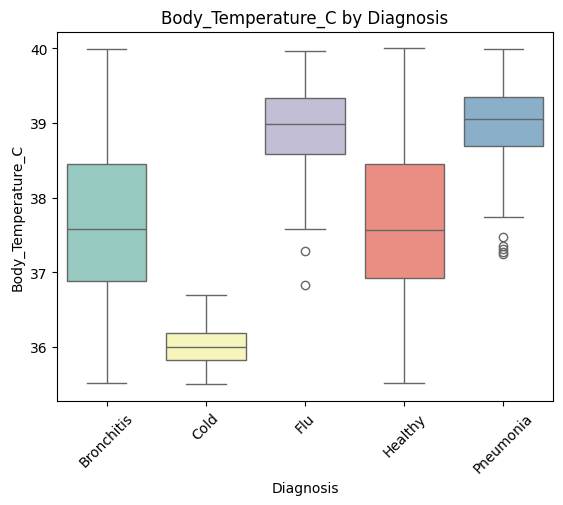

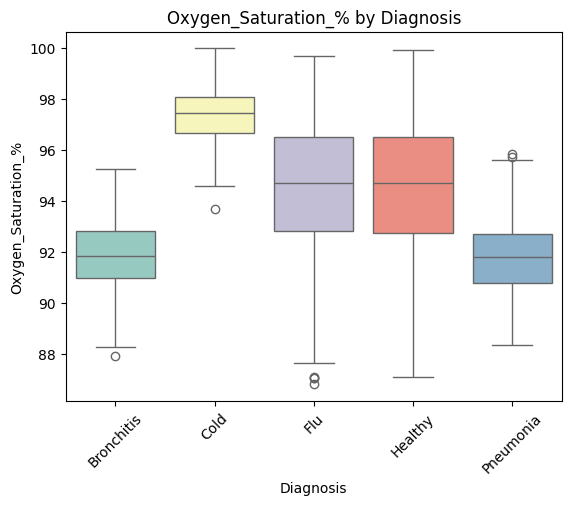

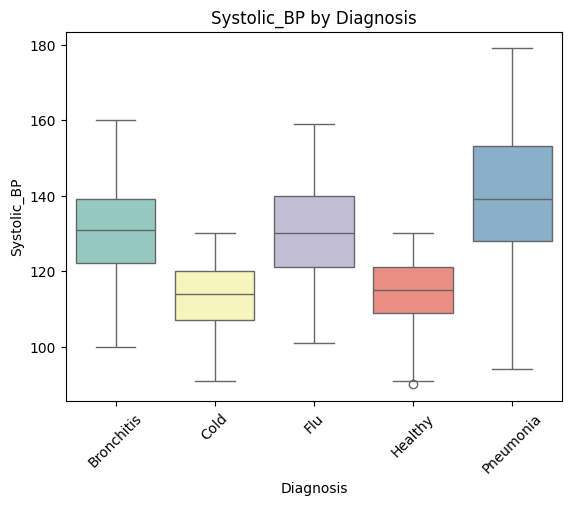

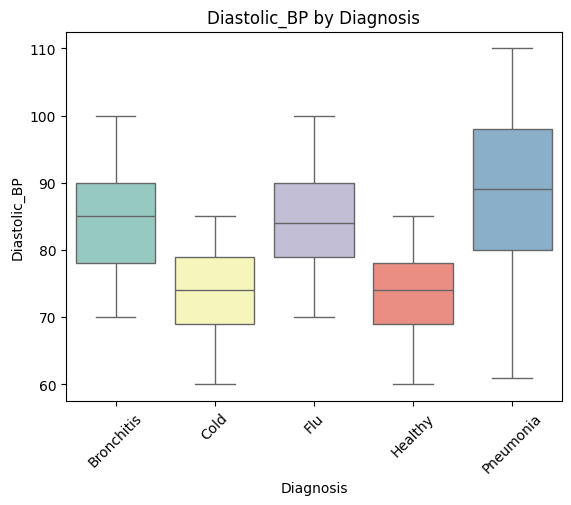

In [10]:
# Boxplots of vitals by Diagnosis
for col in ["Heart_Rate_bpm", "Body_Temperature_C", "Oxygen_Saturation_%", "Systolic_BP", "Diastolic_BP"]:
    if col in df.columns:
        sns.boxplot(data=df, x="Diagnosis", y=col, hue="Diagnosis", palette="Set3", legend=False)
        plt.title(f"{col} by Diagnosis")
        plt.xticks(rotation=45)
        plt.show()


Insights-
-The Pneumonia class stands out clearly from the others across multiple vitals
-The heart rate for Pneumonia is dramatically higher than for any other condition.
-High fever is a key feature for both Flu and Pneumonia
-Temperature is less for cold
-Low oxygen saturation is characteristic of Pneumonia and Bronchitis


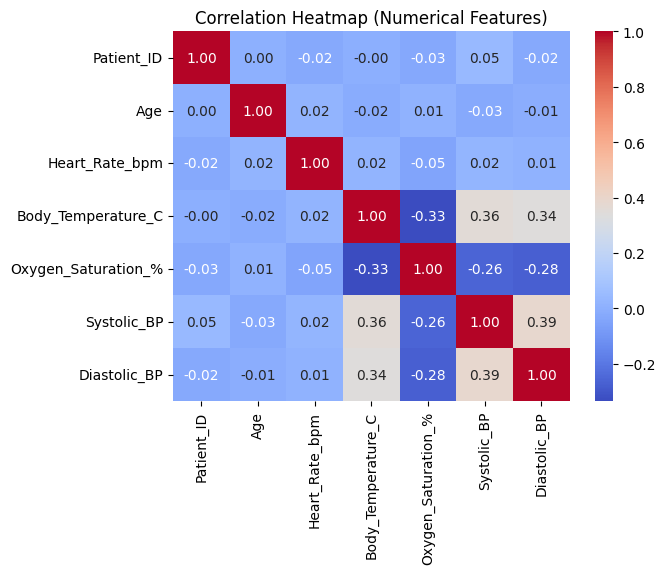

In [ ]:
# Correlation Analysis

num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

-Insights
-Most of the squares in the heatmap are light blue, white, or light orange
-It means that most of the numerical features are independent and not strongly correlated with each other. 

Multivariate Analysis

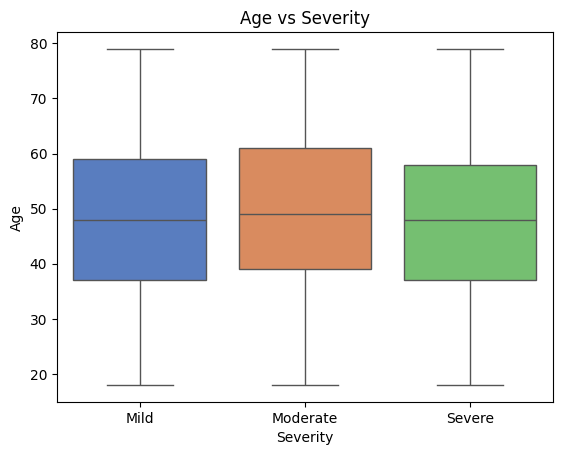

In [11]:
# Age vs Severity
sns.boxplot(data=df, x="Severity", y="Age",hue="Severity" ,palette="muted")
plt.title("Age vs Severity")
plt.show()

Insight-
-there appears to be no clear relationship between a patient's Age and the Severity of their diagnosis.

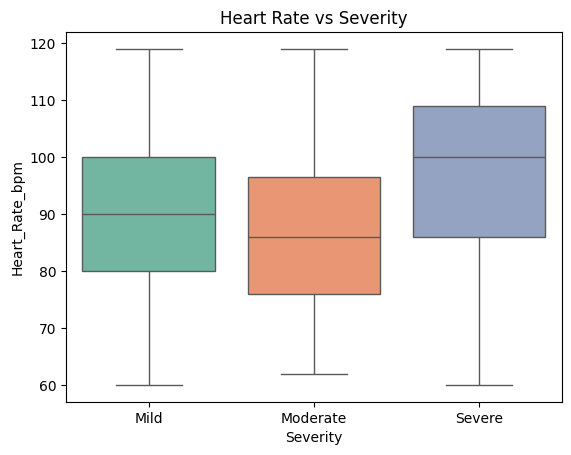

In [12]:
# Heart Rate vs Severity
sns.boxplot(data=df, x="Severity", y="Heart_Rate_bpm",hue="Severity", palette="Set2")
plt.title("Heart Rate vs Severity")
plt.show()

Insights
-Heart rate shows a relationship with severity; the median heart rate for 'Severe' cases is higher than for 'Mild' and 'Moderate'.

In [13]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Disease Diagnosis Comparison lates")

2025/09/02 08:47:39 INFO mlflow.tracking.fluent: Experiment with name 'Disease Diagnosis Comparison lates' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///e:/HealthCareProject/Prediction_module/notebook/mlruns/793583125673476240', creation_time=1756783059165, experiment_id='793583125673476240', last_update_time=1756783059165, lifecycle_stage='active', name='Disease Diagnosis Comparison lates', tags={}>

In [14]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [15]:
# Define Features (X) and Target (y)
# The target variable is 'Diagnosis'

y = df["Diagnosis"]

X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"])

print("\nShape of feature set (X):", X.shape)
print("Shape of target set (y):", y.shape)


Shape of feature set (X): (2000, 10)
Shape of target set (y): (2000,)


In [16]:

# Build the Preprocessing Pipeline

print("\nBuilding the ColumnTransformer preprocessing pipeline...")

# Automatically identify numerical and categorical feature names from X
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nIdentified Numerical Features:")
print(numerical_features)
print("\nIdentified Categorical Features:")
print(categorical_features)


Building the ColumnTransformer preprocessing pipeline...

Identified Numerical Features:
['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']

Identified Categorical Features:
['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']


In [17]:
# Create the preprocessing pipeline for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create the preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:

# Assemble Final Preprocessors for Different Model Types

print("\nAssembling final preprocessors...")

#  Preprocessor for Linear Models 
# This preprocessor scales the numerical data.
linear_model_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# Preprocessor for Tree-Based Models 
tree_model_preprocessor = ColumnTransformer(
    transformers=[
        # For numerical features, we still impute but do not scale
        ('num', SimpleImputer(strategy='median'), numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("\n--- Preprocessing Setup Complete ---")



Assembling final preprocessors...

--- Preprocessing Setup Complete ---


In [ ]:

# Split the Data

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data into 75% for training and 25% for testing
# stratify=y is crucial to maintain the same class proportions in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")



# Define and Train Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier 

# Created a dictionary of full pipelines to test
# Each pipeline combines the appropriate preprocessor with a classifier
# We use class_weight='balanced' to handle the class imbalance
pipelines = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', linear_model_preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', tree_model_preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', tree_model_preprocessor),
        ('classifier', LGBMClassifier(random_state=42, class_weight='balanced'))
    ])
}

# Loop through the pipelines to train, evaluate, and log each one
for name, pipeline in pipelines.items():
    print(f"\n--- Training {name} ---")
    
    # Start an MLflow run for each model
    with mlflow.start_run(run_name=f"{name} (class_weight)"):
        
        # Train the model on the training data
        pipeline.fit(X_train, y_train)
        
        # Make predictions on the unseen test data
        y_pred = pipeline.predict(X_test)
        
        # Get the classification report as a dictionary for easy logging
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # --- MLflow Logging ---
        mlflow.log_param("model_name", name)
        mlflow.log_param("balancing_strategy", "class_weight")
        
        # Log key metrics
        mlflow.log_metric("accuracy", report['accuracy'])
        mlflow.log_metric("pneumonia_recall", report['Pneumonia']['recall'])
        mlflow.log_metric("pneumonia_f1_score", report['Pneumonia']['f1-score'])
        mlflow.log_metric("macro_avg_f1_score", report['macro avg']['f1-score'])
        
        # Log the trained model pipeline
        mlflow.sklearn.log_model(pipeline, "model")
        
        print(f"Classification Report for {name}:")
        print(classification_report(y_test, y_pred))
        print(f"--- Run for {name} logged to MLflow ---")
        print("-" * 50)

Training set shape: (1500, 10)
Testing set shape: (500, 10)

--- Training Logistic Regression ---


2025/09/02 08:48:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:48:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

  Bronchitis       0.89      0.79      0.84       108
        Cold       0.92      0.99      0.95       106
         Flu       0.82      0.76      0.79       109
     Healthy       0.77      0.75      0.76       110
   Pneumonia       0.72      0.90      0.80        67

    accuracy                           0.83       500
   macro avg       0.83      0.84      0.83       500
weighted avg       0.83      0.83      0.83       500

--- Run for Logistic Regression logged to MLflow ---
--------------------------------------------------

--- Training Random Forest ---


2025/09/02 08:48:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:48:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Classification Report for Random Forest:
              precision    recall  f1-score   support

  Bronchitis       0.85      0.81      0.83       108
        Cold       0.94      0.97      0.96       106
         Flu       0.84      0.74      0.79       109
     Healthy       0.74      0.79      0.77       110
   Pneumonia       0.79      0.88      0.83        67

    accuracy                           0.84       500
   macro avg       0.83      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500

--- Run for Random Forest logged to MLflow ---
--------------------------------------------------

--- Training LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 803
[LightGBM] [Info] Number of data points in the train set: 1500, number of used features: 32
[LightGBM] [Info] Start training from score -1.609438
[Lig

e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025/09/02 08:48:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:48:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Classification Report for LightGBM:
              precision    recall  f1-score   support

  Bronchitis       0.83      0.87      0.85       108
        Cold       0.95      0.97      0.96       106
         Flu       0.80      0.76      0.78       109
     Healthy       0.80      0.75      0.78       110
   Pneumonia       0.82      0.87      0.84        67

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500

--- Run for LightGBM logged to MLflow ---
--------------------------------------------------


In [20]:

from imblearn.over_sampling import SMOTE

# 1.Check the counts BEFORE SMOTE
print("--- Class Distribution Before SMOTE ---")
print(y_train.value_counts())

# 2.Apply the preprocessing step
# We need to preprocess the data before giving it to SMOTE
X_train_processed = tree_model_preprocessor.fit_transform(X_train)

# 3.Apply SMOTE
# Create an instance of the SMOTE
smote = SMOTE(random_state=42)

# Fit and resample the processed training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# 4.Check the counts AFTER SMOTE
print("\n--- Class Distribution After SMOTE ---")

print(pd.Series(y_train_resampled).value_counts())

print(f"\nShape of training data before SMOTE: {X_train_processed.shape}")
print(f"Shape of training data after SMOTE:  {X_train_resampled.shape}")

--- Class Distribution Before SMOTE ---
Diagnosis
Healthy       330
Flu           326
Bronchitis    322
Cold          319
Pneumonia     203
Name: count, dtype: int64

--- Class Distribution After SMOTE ---
Diagnosis
Bronchitis    330
Cold          330
Flu           330
Healthy       330
Pneumonia     330
Name: count, dtype: int64

Shape of training data before SMOTE: (1500, 32)
Shape of training data after SMOTE:  (1650, 32)


In [ ]:
# linear_model_preprocessor (with scaling)
# tree_model_preprocessor (without scaling)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier


# 1. Defining SMOTE Pipelines
# Created a dictionary of pipelines that use SMOTE
smote_pipelines = {
    'Logistic Regression with SMOTE': ImbPipeline(steps=[
        ('preprocessor', linear_model_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest with SMOTE': ImbPipeline(steps=[
        ('preprocessor', tree_model_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'LightGBM with SMOTE': ImbPipeline(steps=[
        ('preprocessor', tree_model_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LGBMClassifier(random_state=42))
    ])
}

for name, pipeline in smote_pipelines.items():
    print(f"--- Training {name} ---")
    
    # Start an MLflow run for each SMOTE model
    with mlflow.start_run(run_name=name):
    
        # Train the model
        pipeline.fit(X_train, y_train)

        # Make predictions
        y_pred = pipeline.predict(X_test)

        # Get the report as a dictionary
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # --- MLflow Logging ---
        mlflow.log_param("model_name", name.replace(" with SMOTE", ""))
        mlflow.log_param("balancing_strategy", "SMOTE")
        
        # Log key metrics
        mlflow.log_metric("accuracy", report['accuracy'])
        mlflow.log_metric("pneumonia_recall", report['Pneumonia']['recall'])
        mlflow.log_metric("pneumonia_f1_score", report['Pneumonia']['f1-score'])
        mlflow.log_metric("macro_avg_f1_score", report['macro avg']['f1-score'])

        # Log the trained model pipeline
        mlflow.sklearn.log_model(pipeline, "model")

        print(f"\nClassification Report for {name}:")
        print(classification_report(y_test, y_pred))
        print(f"--- Run for {name} logged to MLflow ---")
        print("-" * 50)

--- Training Logistic Regression with SMOTE ---


2025/09/02 08:49:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:49:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Classification Report for Logistic Regression with SMOTE:
              precision    recall  f1-score   support

  Bronchitis       0.91      0.81      0.85       108
        Cold       0.92      0.99      0.95       106
         Flu       0.82      0.77      0.79       109
     Healthy       0.77      0.76      0.77       110
   Pneumonia       0.76      0.88      0.81        67

    accuracy                           0.84       500
   macro avg       0.83      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500

--- Run for Logistic Regression with SMOTE logged to MLflow ---
--------------------------------------------------
--- Training Random Forest with SMOTE ---


2025/09/02 08:49:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:49:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Classification Report for Random Forest with SMOTE:
              precision    recall  f1-score   support

  Bronchitis       0.86      0.84      0.85       108
        Cold       0.94      0.97      0.96       106
         Flu       0.82      0.75      0.78       109
     Healthy       0.78      0.78      0.78       110
   Pneumonia       0.77      0.87      0.82        67

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500

--- Run for Random Forest with SMOTE logged to MLflow ---
--------------------------------------------------
--- Training LightGBM with SMOTE ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1204
[LightGBM] [Info] Number of data points in the train

e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025/09/02 08:49:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:49:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Classification Report for LightGBM with SMOTE:
              precision    recall  f1-score   support

  Bronchitis       0.81      0.86      0.83       108
        Cold       0.95      0.98      0.97       106
         Flu       0.80      0.74      0.77       109
     Healthy       0.79      0.76      0.78       110
   Pneumonia       0.81      0.84      0.82        67

    accuracy                           0.84       500
   macro avg       0.83      0.84      0.83       500
weighted avg       0.83      0.84      0.83       500

--- Run for LightGBM with SMOTE logged to MLflow ---
--------------------------------------------------


In [ ]:


from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier

# 1. Define the Pipeline to Tune
# Choosing the best performed modal

pipeline_to_tune = Pipeline(steps=[
    ('preprocessor', tree_model_preprocessor),
    ('classifier', LGBMClassifier(random_state=42, class_weight='balanced'))
])

# 2. Define the Parameter Grid
# These are the hyperparameters we want to test.
# Note the 'classifier__' prefix, which tells the pipeline to apply these to the classifier step.
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__num_leaves': [31, 40, 50]
}

# 3. Set Up and Run the Grid Search
# scoring='f1_macro' for imbalanced multi-class problems.
# n_jobs=-1 uses all available CPU cores to speed up the process.
# verbose=2 will print progress updates as it runs.
grid_search = GridSearchCV(
    estimator=pipeline_to_tune, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=3, 
    verbose=2, 
    n_jobs=-1
)

# Start a single MLflow run for the entire tuning process
with mlflow.start_run(run_name="Tuned LightGBM"):

    print("\n--- Starting Hyperparameter Tuning for LightGBM ---")
    grid_search.fit(X_train, y_train)

    # Get the best model found by the grid search
    best_model = grid_search.best_estimator_

    # Make predictions on the unseen test data
    y_pred_tuned = best_model.predict(X_test)
    
    # Get the final report as a dictionary
    report = classification_report(y_test, y_pred_tuned, output_dict=True)

    # --- MLflow Logging ---
    # Log the best parameters found
    mlflow.log_params(grid_search.best_params_)
    
    # Log the best cross-validation score
    mlflow.log_metric("best_cv_f1_macro", grid_search.best_score_)
    
    # Log final test metrics
    mlflow.log_metric("test_accuracy", report['accuracy'])
    mlflow.log_metric("test_pneumonia_recall", report['Pneumonia']['recall'])
    mlflow.log_metric("test_pneumonia_f1_score", report['Pneumonia']['f1-score'])
    mlflow.log_metric("test_macro_avg_f1_score", report['macro avg']['f1-score'])
    
    # Log the best model pipeline
    mlflow.sklearn.log_model(best_model, "model")
    
    print("\nBest parameters found:")
    print(grid_search.best_params_)
    print("\nClassification Report for the Tuned LightGBM Model:")
    print(classification_report(y_test, y_pred_tuned))
    print("--- Tuned LightGBM run logged to MLflow ---")



--- Starting Hyperparameter Tuning for LightGBM ---
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 803
[LightGBM] [Info] Number of data points in the train set: 1500, number of used features: 32
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025/09/02 08:51:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:51:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Best parameters found:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__num_leaves': 31}

Classification Report for the Tuned LightGBM Model:
              precision    recall  f1-score   support

  Bronchitis       0.86      0.84      0.85       108
        Cold       0.95      0.96      0.96       106
         Flu       0.83      0.78      0.80       109
     Healthy       0.79      0.75      0.77       110
   Pneumonia       0.76      0.90      0.82        67

    accuracy                           0.84       500
   macro avg       0.84      0.85      0.84       500
weighted avg       0.84      0.84      0.84       500

--- Tuned LightGBM run logged to MLflow ---


In [ ]:

# 1. Define the Pipeline to Tune
rf_pipeline = Pipeline(steps=[
    ('preprocessor', tree_model_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 2. Define the Parameter Grid for Random Forest
param_grid_rf = {
    'classifier__n_estimators': [100, 200],         # Number of trees in the forest
    'classifier__max_depth': [10, 20, None],       # Maximum depth of the trees
    'classifier__min_samples_split': [2, 5],       # Min samples required to split a node
    'classifier__min_samples_leaf': [1, 2]         # Min samples required at a leaf node
}

# 3. Set Up and Run the Grid Search
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline, 
    param_grid=param_grid_rf, 
    scoring='f1_macro', 
    cv=3, 
    verbose=2, 
    n_jobs=-1
)

with mlflow.start_run(run_name="Tuned Random Forest"):

    print("\n--- Starting Hyperparameter Tuning for Random Forest ---")
    grid_search_rf.fit(X_train, y_train)

    best_rf_model = grid_search_rf.best_estimator_
    y_pred_rf_tuned = best_rf_model.predict(X_test)
    report_rf = classification_report(y_test, y_pred_rf_tuned, output_dict=True)

    # --- MLflow Logging ---
    mlflow.log_params(grid_search_rf.best_params_)
    mlflow.log_metric("best_cv_f1_macro", grid_search_rf.best_score_)
    
    mlflow.log_metric("test_accuracy", report_rf['accuracy'])
    mlflow.log_metric("test_pneumonia_recall", report_rf['Pneumonia']['recall'])
    mlflow.log_metric("test_pneumonia_f1_score", report_rf['Pneumonia']['f1-score'])
    mlflow.log_metric("test_macro_avg_f1_score", report_rf['macro avg']['f1-score'])
    
    mlflow.sklearn.log_model(best_rf_model, "model")

    print("\nBest parameters found for Random Forest:")
    print(grid_search_rf.best_params_)
    print("\nClassification Report for the Tuned Random Forest Model:")
    print(classification_report(y_test, y_pred_rf_tuned))
    print("--- Tuned Random Forest run logged to MLflow ---")


--- Starting Hyperparameter Tuning for Random Forest ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits


2025/09/02 08:51:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 08:51:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Best parameters found for Random Forest:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Classification Report for the Tuned Random Forest Model:
              precision    recall  f1-score   support

  Bronchitis       0.84      0.81      0.82       108
        Cold       0.95      0.99      0.97       106
         Flu       0.83      0.72      0.77       109
     Healthy       0.77      0.81      0.79       110
   Pneumonia       0.79      0.88      0.83        67

    accuracy                           0.84       500
   macro avg       0.83      0.84      0.84       500
weighted avg       0.84      0.84      0.83       500

--- Tuned Random Forest run logged to MLflow ---


Predict

In [2]:
import mlflow
import pandas as pd

best_run_id = '6e1b165cd8704565bffbecb6719d1a21'

# Load the entire model pipeline artifact from the specific run
logged_model = f'runs:/{best_run_id}/model'
model_pipeline = mlflow.sklearn.load_model(logged_model)

print(f"Successfully loaded the model pipeline from run ID: {best_run_id}")

# --- Sample Data for Prediction ---

# Create a DataFrame for a new patient
new_patient_data = pd.DataFrame({
    'Age': [52],
    'Gender': ['Female'],
    'Heart_Rate_bpm': [90],
    'Body_Temperature_C': [38.5],
    'Oxygen_Saturation_%': [94],
    'Blood_Pressure_mmHg': ['140/90'],
    'Symptom_1': ['Cough'],
    'Symptom_2': ['Fatigue'],
    'Symptom_3': ['Nausea'],
})

# --- Prediction Logic ---

if 'Blood_Pressure_mmHg' in new_patient_data.columns:
    new_patient_data[['Systolic_BP', 'Diastolic_BP']] = new_patient_data['Blood_Pressure_mmHg'].str.split('/', expand=True)
    new_patient_data['Systolic_BP'] = pd.to_numeric(new_patient_data['Systolic_BP'])
    new_patient_data['Diastolic_BP'] = pd.to_numeric(new_patient_data['Diastolic_BP'])
    new_patient_data.drop(columns=['Blood_Pressure_mmHg'], inplace=True)
    
# Make the prediction
predicted_diagnosis = model_pipeline.predict(new_patient_data)

print("\n--- Prediction Result ---")
print(f"Sample data for prediction:\n{new_patient_data}")
print(f"\nPredicted Diagnosis: {predicted_diagnosis[0]}")

e:\HealthCareProject\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded the model pipeline from run ID: 6e1b165cd8704565bffbecb6719d1a21


e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Prediction Result ---
Sample data for prediction:
   Age  Gender  Heart_Rate_bpm  Body_Temperature_C  Oxygen_Saturation_%  \
0   52  Female              90                38.5                   94   

  Symptom_1 Symptom_2 Symptom_3  Systolic_BP  Diastolic_BP  
0     Cough   Fatigue    Nausea          140            90  

Predicted Diagnosis: Flu


In [31]:
import pandas as pd
import os

PREDICTIONS_FILE = "../../predictions.csv"

# Example prediction result
predicted_diagnosis = model_pipeline.predict(new_patient_data)[0]

# Prepare result row
module1_result = {
    "Module": "Structured_Model",
    "Patient_ID": int(0),
    "Predicted_Disease": predicted_diagnosis
}

# Convert to DataFrame
df_result = pd.DataFrame([module1_result])

# Append to CSV
if not os.path.exists(PREDICTIONS_FILE):
    df_result.to_csv(PREDICTIONS_FILE, index=False)   # create new file
else:
    df_result.to_csv(PREDICTIONS_FILE, mode="a", index=False, header=False)  # append


e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
